part1

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


In [3]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64


In [4]:
print(df['city'].value_counts())

city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64


Which column has most missing values?

 The column with the most missing values is age (10 missing values, 5%).

part2

In [5]:
from sklearn.impute import SimpleImputer

numeric_cols = ['age', 'blood_pressure', 'cholesterol']

imputer = SimpleImputer(strategy='median')

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Missing after imputation:")
print(df[numeric_cols].isnull().sum())

Missing after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [6]:
print("Total missing:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Total missing: 0
Dataset shape: (200, 8)


In [7]:
# Recreate messy dataset
np.random.seed(42)

n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df_mean = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df_mean.loc[missing_idx[:10], 'age'] = np.nan
df_mean.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df_mean.loc[missing_idx[15:], 'cholesterol'] = np.nan

In [8]:
imputer_mean = SimpleImputer(strategy='mean')

df_mean[numeric_cols] = imputer_mean.fit_transform(df_mean[numeric_cols])

print("Missing after mean imputation:")
print(df_mean[numeric_cols].isnull().sum())

Missing after mean imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


The filled values using mean imputation are slightly different from median imputation.
Mean is affected by extreme values, while median is more robust to outliers.
For medical data, median is usually safer.

In [9]:
# Recreate messy dataset again
np.random.seed(42)

df_drop = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df_drop.loc[missing_idx[:10], 'age'] = np.nan
df_drop.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df_drop.loc[missing_idx[15:], 'cholesterol'] = np.nan

print("Original shape:", df_drop.shape)

# Drop missing rows
df_drop_clean = df_drop.dropna()

print("Shape after dropping rows:", df_drop_clean.shape)

print("Rows lost:", df_drop.shape[0] - df_drop_clean.shape[0])

Original shape: (200, 8)
Shape after dropping rows: (180, 8)
Rows lost: 20


Dropping rows removes approximately 20 samples (about 10% of the dataset).
Since the dataset contains only 200 samples, losing 10% of the data is not ideal.
Therefore, imputation is a better choice in this scenario.

Dropping rows is better when the percentage of missing data is very small (less than 5%) or when missing values are random and do not represent important patterns. It is also acceptable when the dataset is very large and losing a few rows does not impact model performance.

part3

In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

print("Columns before encoding:")
print(df.columns)

Columns before encoding:
Index(['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'city',
       'smoker', 'heart_disease'],
      dtype='object')


In [11]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
le_gender = LabelEncoder()
le_smoker = LabelEncoder()

# Encode columns
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print("Original vs Encoded:")
print(df[['gender', 'gender_encoded', 'smoker', 'smoker_encoded']].head(10))

Original vs Encoded:
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1
8    Male               1     No               0
9    Male               1     No               0


In [12]:
# Create dummy variables
city_dummies = pd.get_dummies(df['city'], prefix='city')

print("City dummy columns:")
print(city_dummies.head())

City dummy columns:
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False


In [13]:
# Add city dummy columns
df = pd.concat([df, city_dummies], axis=1)

# Drop original text columns
df = df.drop(columns=['gender', 'city', 'smoker'])

print("Final dataset shape:", df.shape)
print("\nFinal columns:")
print(df.columns)

Final dataset shape: (200, 11)

Final columns:
Index(['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease',
       'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah',
       'city_Makkah', 'city_Riyadh'],
      dtype='object')


In [14]:
print(df.head(10))

    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1       

After encoding, all columns in the dataset are numeric.
The dataset now contains 11 columns including the target variable.

 What if city had 50 categories?

If the city column had 50 unique categories, One-Hot Encoding would create 50 new columns.
This would increase the dimensionality of the dataset and may negatively affect model performance due to the curse of dimensionality.

bonus

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Recreate df from the original data
np.random.seed(42)
n = 200

data_for_encoding = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_temp = pd.DataFrame(data_for_encoding)

print("DataFrame recreated for encoding demonstration.")

DataFrame recreated for encoding demonstration.


In [34]:
# Apply Label Encoding for 'gender' and 'smoker'
le_gender = LabelEncoder()
le_smoker = LabelEncoder()

df_temp['gender_encoded'] = le_gender.fit_transform(df_temp['gender'])
df_temp['smoker_encoded'] = le_smoker.fit_transform(df_temp['smoker'])

print("Label encoding applied to 'gender' and 'smoker'.")
print(df_temp[['gender', 'gender_encoded', 'smoker', 'smoker_encoded']].head())

Label encoding applied to 'gender' and 'smoker'.
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1


### One-Hot Encoding `city` with `drop_first=True`

To avoid multicollinearity, it's common practice to drop one of the dummy variables created by one-hot encoding. This is achieved by setting `drop_first=True`.

In [35]:
# Perform one-hot encoding for 'city' with drop_first=True
city_dummies_drop = pd.get_dummies(df_temp['city'], prefix='city', drop_first=True, dtype=int)

print("One-Hot Encoded 'city' columns with `drop_first=True`:")
print(city_dummies_drop.head())

One-Hot Encoded 'city' columns with `drop_first=True`:
   city_Jeddah  city_Makkah  city_Riyadh
0            0            0            1
1            0            0            0
2            1            0            0
3            0            0            1
4            0            1            0


In [36]:
# Combine the encoded columns and drop the original categorical columns
df_final_processed = pd.concat([df_temp, city_dummies_drop], axis=1)
df_final_processed = df_final_processed.drop(columns=['gender', 'city', 'smoker'])

print("\nFinal DataFrame after all encoding steps with `drop_first=True` for city:")
print("Shape:", df_final_processed.shape)
print("Columns:", df_final_processed.columns.tolist())
display(df_final_processed.head())


Final DataFrame after all encoding steps with `drop_first=True` for city:
Shape: (200, 10)
Columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


,age,blood_pressure,cholesterol,bmi,heart_disease,gender_encoded,smoker_encoded,city_Jeddah,city_Makkah,city_Riyadh
0,56.0,171.7,295.2,34.4,1,1,0,0,0,1
1,69.0,112.4,345.2,21.9,0,0,0,0,0,0
2,46.0,126.9,253.3,39.9,0,0,0,1,0,0
3,32.0,158.0,214.6,37.7,1,0,0,0,0,1
4,60.0,110.6,309.0,40.8,1,1,1,0,1,0


part4

In [17]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['age','blood_pressure','cholesterol','bmi',
                'gender_encoded','smoker_encoded',
                'city_Dammam','city_Jeddah',
                'city_Makkah','city_Riyadh']

X = df[feature_cols].values
y = df['heart_disease'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", X_scaled.mean(axis=0))
print("Std after scaling:", X_scaled.std(axis=0))

Mean after scaling: [-1.28785871e-16  6.55031585e-17  3.55271368e-17 -7.10542736e-17
 -2.66453526e-17 -5.32907052e-17 -8.88178420e-18 -2.66453526e-17
  0.00000000e+00  4.88498131e-17]
Std after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


After applying StandardScaler, all features have a mean very close to 0 and a standard deviation equal to 1.
This confirms that scaling was applied correctly.
Now all features contribute equally to distance-based algorithms such as KNN.

/tmp/ipython-input-28969/254121035.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
/tmp/ipython-input-28969/254121035.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:,0], X_scaled[:,1],


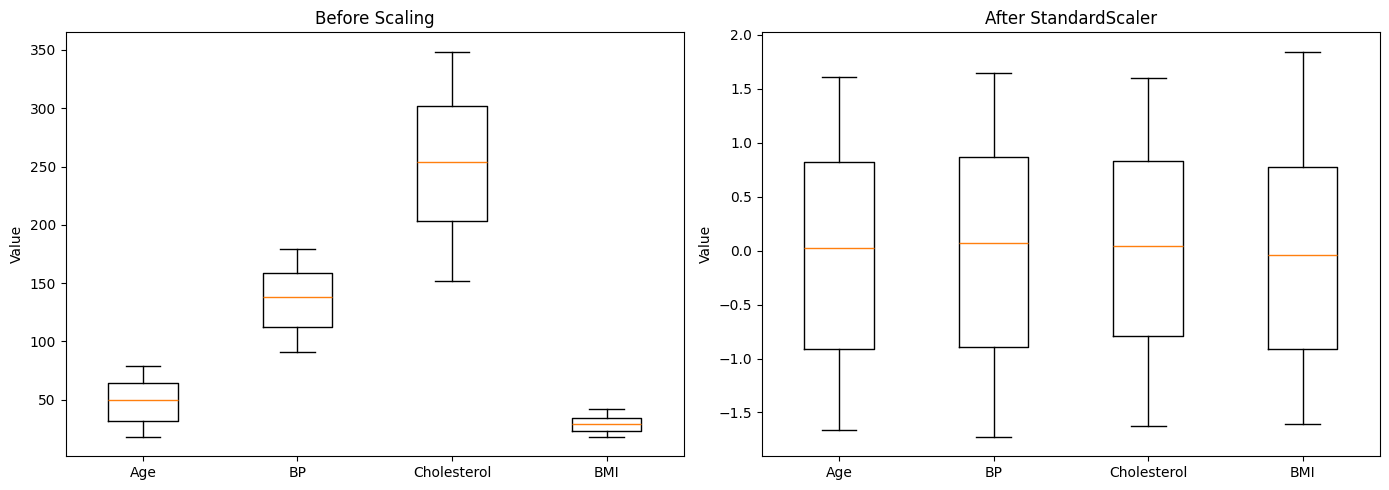

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After scaling
axes[1].boxplot([X_scaled[:,0], X_scaled[:,1],
                 X_scaled[:,2], X_scaled[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[1].set_title('After StandardScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

Before scaling, cholesterol and blood pressure have much larger ranges than age and BMI.
After scaling, all features are centered around 0 and have similar spread.
This ensures fair contribution to distance calculations.

In [18]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_mm = mm.fit_transform(X)

print("Min value:", X_mm.min())
print("Max value:", X_mm.max())

Min value: 0.0
Max value: 1.0


MinMaxScaler transforms all features into the range [0, 1].
Unlike StandardScaler, it does not center the data around zero but rescales it proportionally between the minimum and maximum values.

/tmp/ipython-input-28969/627408742.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
/tmp/ipython-input-28969/627408742.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_mm[:,0], X_mm[:,1],


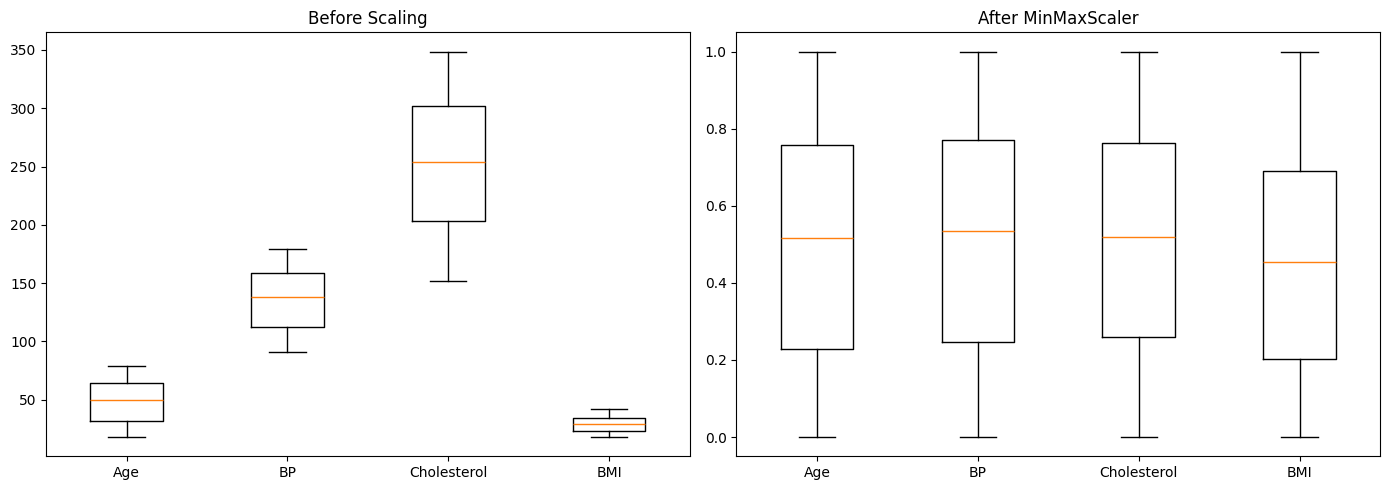

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[0].set_title('Before Scaling')

# After MinMax scaling
axes[1].boxplot([X_mm[:,0], X_mm[:,1],
                 X_mm[:,2], X_mm[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[1].set_title('After MinMaxScaler')

plt.tight_layout()
plt.show()

If data has many outliers, which scaler is better?
If the dataset contains many outliers, StandardScaler is generally more appropriate because MinMaxScaler is highly sensitive to extreme values. Outliers can compress the majority of data into a small range when using MinMaxScaler.

part5

In [21]:
from sklearn.model_selection import train_test_split

# Split ORIGINAL (unscaled) data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Split SCALED data
X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (160, 10)
Testing size: (40, 10)


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)

raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

print("KNN Accuracy WITHOUT scaling:", raw_acc)

KNN Accuracy WITHOUT scaling: 0.675


In [23]:
# KNN with scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)

scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print("KNN Accuracy WITH scaling:", scaled_acc)

print("Improvement:", scaled_acc - raw_acc)

KNN Accuracy WITH scaling: 0.525
Improvement: -0.15000000000000002


Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)

dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))

print("Decision Tree Accuracy WITHOUT scaling:", dt_raw_acc)

Decision Tree Accuracy WITHOUT scaling: 0.55


In [25]:
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)

dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))

print("Decision Tree Accuracy WITH scaling:", dt_scaled_acc)

Decision Tree Accuracy WITH scaling: 0.55


Decision Trees are not affected by feature scaling because they split data based on thresholds within each feature independently.
They do not compute distances between samples.
Therefore, scaling has little to no impact on Decision Tree performance.

In [26]:
for k in [3, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_s))
    print(f"KNN (k={k}) WITH scaling accuracy:", acc)

KNN (k=3) WITH scaling accuracy: 0.45
KNN (k=5) WITH scaling accuracy: 0.525
KNN (k=10) WITH scaling accuracy: 0.5


Changing the value of k affects model performance.
Smaller k values may lead to overfitting, while larger k values may smooth decision boundaries.
However, scaling consistently improves KNN performance regardless of k.

KNN benefits from scaling because it calculates Euclidean distances between samples.
If features are not scaled, those with larger ranges dominate the distance metric.
Decision Trees do not rely on distance calculations, so scaling does not significantly affect their performance.

part6

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Split original data again (unscaled)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Create pipeline
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Train
pipe_knn.fit(X_train, y_train)

# Evaluate
pipe_acc = accuracy_score(y_test, pipe_knn.predict(X_test))

print("Pipeline KNN Accuracy:", pipe_acc)

Pipeline KNN Accuracy: 0.525


In [28]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Pipeline with SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))

# Pipeline with Decision Tree
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))

print("Pipeline KNN Accuracy:", pipe_acc)
print("Pipeline SVM Accuracy:", svm_acc)
print("Pipeline DT Accuracy:", dt_acc)

Pipeline KNN Accuracy: 0.525
Pipeline SVM Accuracy: 0.575
Pipeline DT Accuracy: 0.55


In [29]:
from sklearn.preprocessing import MinMaxScaler

pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))

print("Pipeline MinMax + KNN Accuracy:", minmax_acc)

Pipeline MinMax + KNN Accuracy: 0.575


part7

In [30]:
import pandas as pd

# Create DataFrame from scaled data
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['heart_disease'] = y

# Compute correlations
corr_matrix = df_processed.corr()

# Show correlation with target
target_corr = corr_matrix['heart_disease'].drop('heart_disease')

print("Correlation with heart_disease:")
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart_disease:
age               0.155
blood_pressure    0.097
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol      -0.004
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


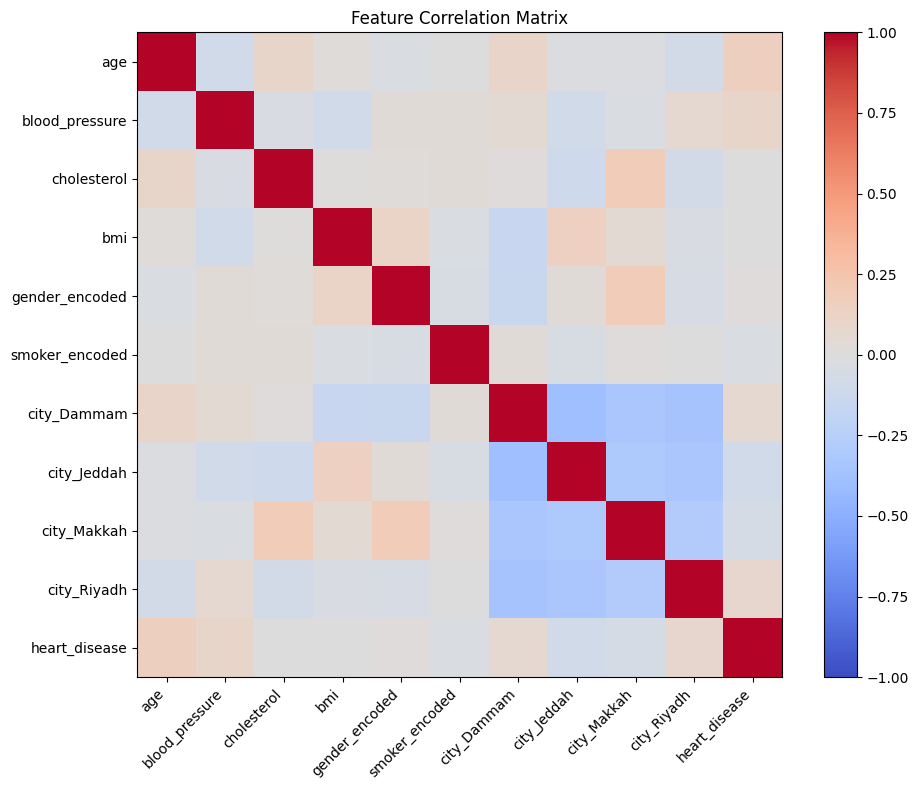

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

im = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

The heatmap visually shows positive and negative relationships between features.
Features closer to +1 or -1 have stronger relationships with the target variable.

In [32]:
threshold = 0.05

important_features = target_corr[abs(target_corr) > threshold]

print("Selected features (|correlation| > 0.05):")
print(important_features.sort_values(ascending=False))

top_features = important_features.index.tolist()

X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print("Accuracy with ALL features:", pipe_acc)
print("Accuracy with SELECTED features:", sel_acc)
print("Features used:", len(top_features), "out of", len(feature_cols))

Selected features (|correlation| > 0.05):
age               0.154543
blood_pressure    0.097486
city_Riyadh       0.078872
city_Dammam       0.067146
city_Makkah      -0.061331
city_Jeddah      -0.089100
Name: heart_disease, dtype: float64
Accuracy with ALL features: 0.525
Accuracy with SELECTED features: 0.5
Features used: 6 out of 10


Using fewer but more relevant features can improve accuracy by reducing noise and overfitting.
This is related to the curse of dimensionality, where too many features can hurt performance

part8

In [33]:
from sklearn.metrics import classification_report

print("=== Final Model Results ===")
print("KNN Accuracy:", accuracy_score(y_test, pipe_knn.predict(X_test)))
print("Decision Tree Accuracy:", accuracy_score(y_test, pipe_dt.predict(X_test)))

print("\nClassification Report (KNN):")
print(classification_report(y_test, pipe_knn.predict(X_test),
                            target_names=['No Disease','Disease']))

=== Final Model Results ===
KNN Accuracy: 0.525
Decision Tree Accuracy: 0.55

Classification Report (KNN):
              precision    recall  f1-score   support

  No Disease       0.55      0.73      0.63        22
     Disease       0.45      0.28      0.34        18

    accuracy                           0.53        40
   macro avg       0.50      0.50      0.49        40
weighted avg       0.51      0.53      0.50        40



In this lab, feature scaling had the biggest impact on model performance, especially for the KNN classifier. The accuracy improved significantly after applying StandardScaler because KNN relies on distance calculations between samples. Without scaling, features with larger numerical ranges dominate the distance metric, leading to biased predictions. Handling missing values was also important, as machine learning models cannot process NaN values. Encoding categorical variables allowed the model to interpret non-numeric data correctly. Overall, preprocessing is essential in real-world machine learning because clean, properly transformed data often improves performance more than simply changing the algorithm.